In [35]:
!pip install -q pdfplumber sentence-transformers scikit-learn nltk xgboost

In [36]:
import zipfile, os, re
import numpy as np
import pandas as pd
import pdfplumber

zip_path     = "/content/AI-Screening-Dataset-01.zip"
extract_path = "/content/dataset"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
dataset_path = "/content/dataset/AI-Screening-Dataset-01"

data = []
for category in os.listdir(dataset_path):
    cat_path = os.path.join(dataset_path, category)
    if not os.path.isdir(cat_path): continue
    for file in os.listdir(cat_path):
        if not file.endswith(".pdf"): continue
        text = ""
        try:
            with pdfplumber.open(os.path.join(cat_path, file)) as pdf:
                for page in pdf.pages:
                    t = page.extract_text()
                    if t: text += t + " "
            if text.strip():
                data.append({"resume_text": text.strip(), "category": category, "filename": file})
        except: pass

df = pd.DataFrame(data)
print(f"Total CVs: {len(df)}")
print(df['category'].value_counts().to_string())

Total CVs: 2483
category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      119
CHEF                      118
ENGINEERING               118
FINANCE                   118
ACCOUNTANT                118
ADVOCATE                  118
AVIATION                  117
FITNESS                   117
SALES                     116
HEALTHCARE                115
BANKING                   115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22


In [37]:
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
nltk.download('wordnet', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('omw-1.4', quiet=True)

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

DOMAIN = {
    r'c\+\+':'cplusplus', r'\.net':'dotnet', r'node\.js':'nodejs',
    r'react\.js':'reactjs', r'next\.js':'nextjs', r'vue\.js':'vuejs',
    r'express\.js':'expressjs', r'asp\.net':'aspnet', r'ci/cd':'cicd',
    r'rest api':'restapi', r'machine learning':'machinelearning',
    r'deep learning':'deeplearning', r'natural language':'naturallanguage',
    r'data science':'datascience', r'computer vision':'computervision',
    r'sql server':'sqlserver', r'power bi':'powerbi',
}

def clean_text(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    for p, r in DOMAIN.items():
        text = re.sub(p, r, text)
    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r'http\S+', ' ', text)
    text = re.sub(r'\+?[\d\s\-\(\)]{7,}', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    tokens = [lemmatizer.lemmatize(w) for w in text.split()
              if len(w) > 2 and w not in stop_words]
    return " ".join(tokens).strip()

df['cleaned_text'] = df['resume_text'].apply(clean_text)
df = df[df['cleaned_text'].str.len() > 50].reset_index(drop=True)
print(f"CVs after cleaning: {len(df)}")

CVs after cleaning: 2483


In [38]:
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import normalize

print("Loading SentenceTransformer (all-mpnet-base-v2)...")
embedder = SentenceTransformer('all-mpnet-base-v2')

print("Encoding all CVs — this is a one-time step...")
cv_embeddings = embedder.encode(
    df['cleaned_text'].tolist(),
    show_progress_bar=True,
    batch_size=32
)
cv_embeddings = normalize(cv_embeddings)   # L2 normalize for cosine similarity
print(f"CV embeddings shape: {cv_embeddings.shape}")
# Shape: (n_cvs, 768) — each CV is a 768-dim vector

Loading SentenceTransformer (all-mpnet-base-v2)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding all CVs — this is a one-time step...


Batches:   0%|          | 0/78 [00:00<?, ?it/s]

CV embeddings shape: (2483, 768)


In [39]:
from sklearn.feature_extraction.text import TfidfVectorizer

# One merged document per category
cat_docs   = df.groupby('category')['cleaned_text'].apply(' '.join)
categories = list(cat_docs.index)

cat_tfidf  = TfidfVectorizer(
    max_features=30000, ngram_range=(1, 2),
    stop_words='english', sublinear_tf=True
)
cat_matrix = cat_tfidf.fit_transform(cat_docs.values)
cat_vocab  = np.array(cat_tfidf.get_feature_names_out())

# Build a short JD string from top-50 terms of each category
category_jds = {}
for i, cat in enumerate(categories):
    scores   = cat_matrix[i].toarray()[0]
    top_idx  = scores.argsort()[::-1][:50]
    terms    = cat_vocab[top_idx]
    jd_text  = f"Hiring for {cat.lower()} role. Required skills and experience: {', '.join(terms)}."
    category_jds[cat] = jd_text

print(f"Built JDs for {len(category_jds)} categories.")
print("\nExample JD for first category:")
first_cat = categories[0]
print(f"  [{first_cat}] {category_jds[first_cat][:150]}...")

Built JDs for 24 categories.

Example JD for first category:
  [ACCOUNTANT] Hiring for accountant role. Required skills and experience: accountant summary, usafe, accountant company, current accountant, accountant current, acc...


In [40]:
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

# ── Helper: extract years of experience ──────────────────────────────────────
def get_experience_score(text):
    pattern = re.compile(
        r'(\d+)[\s\+]*(year|yr)s?[\s\w]{0,10}(experience|exp|work)',
        re.IGNORECASE
    )
    matches = pattern.findall(text)
    if matches:
        years = max(int(m[0]) for m in matches if int(m[0]) < 50)
    else:
        year_mentions = re.findall(r'\b(19|20)\d{2}\b', text)
        years = max(0, len(set(year_mentions)) - 1)
    return min(years, 15) / 15.0

# ── Helper: skill match score ─────────────────────────────────────────────────
def get_skill_match(cv_text, jd_text):
    # Extract candidate skill tokens from JD (length 3–20, not stopwords)
    jd_tokens = set(
        w for w in jd_text.lower().split()
        if len(w) > 3 and w not in stop_words
    )
    cv_tokens = set(cv_text.lower().split())
    if not jd_tokens: return 0.0
    return len(jd_tokens & cv_tokens) / len(jd_tokens)

# ── Build feature vector for one (JD embedding, CV embedding, texts) pair ────
def build_feature_vector(jd_emb, cv_emb, cv_raw_text, jd_clean_text, cv_clean_text):
    """
    jd_emb, cv_emb : 1D normalized numpy arrays of shape (768,)
    Returns a 1D feature vector.
    """
    cosine   = float(np.dot(jd_emb, cv_emb))              # scalar
    dot      = float(np.dot(jd_emb, cv_emb))              # same as cosine when normalized
    diff     = np.abs(jd_emb - cv_emb)                    # 768-dim
    prod     = jd_emb * cv_emb                             # 768-dim
    skill    = get_skill_match(cv_clean_text, jd_clean_text)  # scalar
    exp      = get_experience_score(cv_raw_text)           # scalar

    return np.concatenate([[cosine, dot, skill, exp], diff, prod])
    # Total dims: 4 + 768 + 768 = 1540

print("Feature builder ready.")
print(f"Feature vector size: {4 + 768 + 768} dimensions per (JD, CV) pair")

Feature builder ready.
Feature vector size: 1540 dimensions per (JD, CV) pair


In [47]:
# ── Encode all category JDs ───────────────────────────────────────────────────
print("Encoding category JDs...")
jd_texts_list    = [category_jds[cat] for cat in categories]
jd_clean_list    = [clean_text(jd) for jd in jd_texts_list]
jd_embeddings    = embedder.encode(jd_texts_list, show_progress_bar=True, batch_size=32)
jd_embeddings    = normalize(jd_embeddings)
cat_to_jd_emb    = {cat: jd_embeddings[i] for i, cat in enumerate(categories)}
cat_to_jd_clean  = {cat: jd_clean_list[i] for i, cat in enumerate(categories)}
print(f"JD embeddings shape: {jd_embeddings.shape}")

Encoding category JDs...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

JD embeddings shape: (24, 768)


In [48]:
# ── Build training pairs ──────────────────────────────────────────────────────
# Strategy: for each CV, pair it with:
#   - its TRUE category JD  → label 1
#   - N_NEG random other JDs → label 0
# This gives us a balanced training set.

N_NEG = 3   # negatives per positive (3:1 ratio)

X_pairs = []
y_labels = []
rng = np.random.RandomState(42)

print("Building training pairs...")
for idx, row in df.iterrows():
    cv_emb   = cv_embeddings[idx]
    cv_cat   = row['category']
    cv_text  = row['resume_text']
    cv_clean = row['cleaned_text']

    # Positive: true category JD
    jd_emb   = cat_to_jd_emb[cv_cat]
    jd_clean = cat_to_jd_clean[cv_cat]
    feat     = build_feature_vector(jd_emb, cv_emb, cv_text, jd_clean, cv_clean)
    X_pairs.append(feat)
    y_labels.append(1)

    # Negatives: random other category JDs
    other_cats = [c for c in categories if c != cv_cat]
    neg_cats   = rng.choice(other_cats, size=min(N_NEG, len(other_cats)), replace=False)
    for neg_cat in neg_cats:
        jd_emb   = cat_to_jd_emb[neg_cat]
        jd_clean = cat_to_jd_clean[neg_cat]
        feat     = build_feature_vector(jd_emb, cv_emb, cv_text, jd_clean, cv_clean)
        X_pairs.append(feat)
        y_labels.append(0)

X_pairs  = np.array(X_pairs,  dtype=np.float32)
y_labels = np.array(y_labels, dtype=np.int32)

print(f"Training pairs built: {len(X_pairs)}")
print(f"  Positive (relevant)    : {y_labels.sum()}")
print(f"  Negative (not relevant): {(y_labels == 0).sum()}")
print(f"  Feature vector size    : {X_pairs.shape[1]}")

Building training pairs...
Training pairs built: 9932
  Positive (relevant)    : 2483
  Negative (not relevant): 7449
  Feature vector size    : 1540


In [49]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model   import LogisticRegression
from sklearn.ensemble       import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics        import accuracy_score, classification_report, roc_auc_score
from xgboost                import XGBClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X_pairs, y_labels,
    test_size=0.2,
    random_state=42,
    stratify=y_labels
)
print(f"Train: {X_train.shape}  Test: {X_test.shape}")

Train: (7945, 1540)  Test: (1987, 1540)


In [50]:
# ── Model A: Logistic Regression ──────────────────────────────────────────────
print("Training Logistic Regression...")
lr = LogisticRegression(C=1.0, max_iter=1000, solver='saga', n_jobs=-1, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr  = lr.predict(X_test)
y_prob_lr  = lr.predict_proba(X_test)[:, 1]
acc_lr     = accuracy_score(y_test, y_pred_lr)
auc_lr     = roc_auc_score(y_test, y_prob_lr)
print(f"  Accuracy: {acc_lr*100:.1f}%   AUC: {auc_lr:.4f}")

Training Logistic Regression...
  Accuracy: 90.5%   AUC: 0.9403


In [51]:
# ── Model B: XGBoost ─────────────────────────────────────────────────────────
print("Training XGBoost...")
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=50)
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]
acc_xgb    = accuracy_score(y_test, y_pred_xgb)
auc_xgb    = roc_auc_score(y_test, y_prob_xgb)
print(f"  Accuracy: {acc_xgb*100:.1f}%   AUC: {auc_xgb:.4f}")

Training XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:27:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[0]	validation_0-logloss:0.53883
[50]	validation_0-logloss:0.27369
[100]	validation_0-logloss:0.24583
[150]	validation_0-logloss:0.23509
[200]	validation_0-logloss:0.23323
[250]	validation_0-logloss:0.23282
[299]	validation_0-logloss:0.23559
  Accuracy: 91.9%   AUC: 0.9499


In [52]:
# ── Model C: Random Forest ────────────────────────────────────────────────────
print("Training Random Forest...")
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf  = rf.predict(X_test)
y_prob_rf  = rf.predict_proba(X_test)[:, 1]
acc_rf     = accuracy_score(y_test, y_pred_rf)
auc_rf     = roc_auc_score(y_test, y_prob_rf)
print(f"  Accuracy: {acc_rf*100:.1f}%   AUC: {auc_rf:.4f}")

Training Random Forest...
  Accuracy: 87.6%   AUC: 0.9290


In [53]:
# ── Summary ───────────────────────────────────────────────────────────────────
results = {
    'Logistic Regression': (acc_lr,  auc_lr,  lr,  y_prob_lr),
    'XGBoost':             (acc_xgb, auc_xgb, xgb, y_prob_xgb),
    'Random Forest':       (acc_rf,  auc_rf,  rf,  y_prob_rf),
}

print("\n── Model Comparison ─────────────────────────────────────")
print(f"  {'Model':<22} {'Accuracy':>10} {'AUC-ROC':>10}")
print("  " + "-" * 44)
for name, (acc, auc, _, __) in sorted(results.items(), key=lambda x: -x[1][1]):
    flag = " ✓" if auc >= 0.90 else ""
    print(f"  {name:<22} {acc*100:>9.1f}% {auc:>10.4f}{flag}")

# Pick best by AUC (better metric than accuracy for ranking)
best_name  = max(results, key=lambda k: results[k][1])
best_model = results[best_name][2]
print(f"\nBest model: {best_name}")


── Model Comparison ─────────────────────────────────────
  Model                    Accuracy    AUC-ROC
  --------------------------------------------
  XGBoost                     91.9%     0.9499 ✓
  Logistic Regression         90.5%     0.9403 ✓
  Random Forest               87.6%     0.9290 ✓

Best model: XGBoost


In [54]:
def score_all_cvs_for_job(jd_text, model):
    """
    Given a job description and trained model,
    returns a DataFrame of all CVs with their relevance probability.
    """
    jd_clean = clean_text(jd_text)
    jd_emb   = normalize([embedder.encode(jd_text)])[0]

    features = []
    for idx, row in df.iterrows():
        feat = build_feature_vector(
            jd_emb,
            cv_embeddings[idx],
            row['resume_text'],
            jd_clean,
            row['cleaned_text']
        )
        features.append(feat)

    features = np.array(features, dtype=np.float32)
    probs    = model.predict_proba(features)[:, 1]  # P(relevant)

    result = df[['filename', 'category']].copy()
    result['ai_score'] = (probs * 100).round(1)
    return result.sort_values('ai_score', ascending=False).reset_index(drop=True)


# Evaluate Precision@K across all categories
K_VALUES = [5, 10, 20]
precision_rows = []

print("Evaluating Precision@K for each category...")
print("-" * 65)

for cat in sorted(categories):
    ranked = score_all_cvs_for_job(category_jds[cat], best_model)
    row    = {'category': cat, 'n_cvs': (df['category'] == cat).sum()}
    for k in K_VALUES:
        top_cats   = ranked.head(k)['category'].values
        precision  = (top_cats == cat).sum() / k
        row[f'P@{k}'] = round(precision * 100, 1)
    precision_rows.append(row)

prec_df = pd.DataFrame(precision_rows).set_index('category')
print(prec_df.to_string())

print("\n" + "=" * 55)
print("MEAN Precision@K across all categories:")
for k in K_VALUES:
    mean_p = prec_df[f'P@{k}'].mean()
    flag   = ' ✓ TARGET MET (75%)' if mean_p >= 75 else ' ✗ below 75%'
    print(f"  P@{k:<3}  =  {mean_p:.1f}%  {flag}")

Evaluating Precision@K for each category...
-----------------------------------------------------------------
                        n_cvs    P@5   P@10   P@20
category                                          
ACCOUNTANT                118  100.0  100.0   95.0
ADVOCATE                  118  100.0  100.0  100.0
AGRICULTURE                63  100.0  100.0  100.0
APPAREL                    97   60.0   80.0   90.0
ARTS                      103   80.0   90.0   95.0
AUTOMOBILE                 36  100.0   90.0   95.0
AVIATION                  117  100.0  100.0  100.0
BANKING                   115  100.0  100.0   85.0
BPO                        22  100.0  100.0   95.0
BUSINESS-DEVELOPMENT      119  100.0  100.0  100.0
CHEF                      118  100.0  100.0  100.0
CONSTRUCTION              112  100.0  100.0  100.0
CONSULTANT                115  100.0  100.0   95.0
DESIGNER                  107   80.0   90.0   95.0
DIGITAL-MEDIA              96  100.0  100.0   90.0
ENGINEERING            

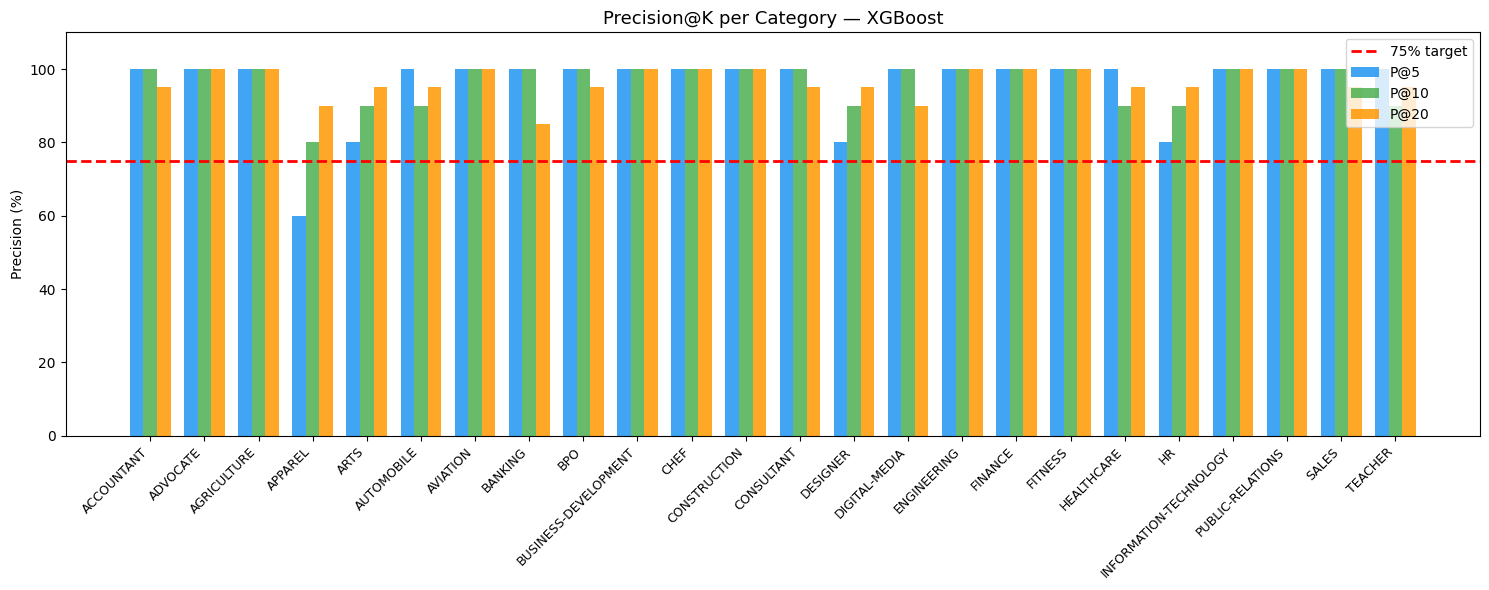

In [55]:
# Precision@K bar chart
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(15, 6))
x     = np.arange(len(prec_df))
width = 0.25
colors = ['#2196F3', '#4CAF50', '#FF9800']

for i, k in enumerate(K_VALUES):
    ax.bar(x + i*width, prec_df[f'P@{k}'], width,
           label=f'P@{k}', color=colors[i], alpha=0.85)

ax.axhline(75, color='red', linestyle='--', linewidth=2, label='75% target')
ax.set_xticks(x + width)
ax.set_xticklabels(prec_df.index, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Precision (%)')
ax.set_title(f'Precision@K per Category — {best_name}', fontsize=13)
ax.legend()
ax.set_ylim(0, 110)
plt.tight_layout()
plt.savefig('/content/precision_k.png', dpi=150)
plt.show()

In [56]:
# ══════════════════════════════════════════════════
# RECRUITER: paste your job description here
# ══════════════════════════════════════════════════

MY_JOB = """
Job Title: Senior Full Stack React Developer

We are looking for a Full Stack Developer with strong expertise
in React.js and Node.js to join our engineering team.

Required:
- 3+ years React.js, JavaScript ES6+, HTML5, CSS3
- Node.js and Express.js backend development
- MongoDB, REST APIs, Git, JWT, OAuth
- AWS, Docker, CI/CD pipelines

Nice to have: TypeScript, Redux, GraphQL
"""

TOP_K = 15
# ══════════════════════════════════════════════════

ranked_cvs = score_all_cvs_for_job(MY_JOB, best_model)
ranked_cvs.index += 1
ranked_cvs.index.name = 'Rank'

print(f"Top {TOP_K} CVs for your job posting:")
print("=" * 65)
print(ranked_cvs.head(TOP_K).to_string())

Top 15 CVs for your job posting:
          filename                category   ai_score
Rank                                                 
1     83816738.pdf  INFORMATION-TECHNOLOGY  95.000000
2     20674668.pdf  INFORMATION-TECHNOLOGY  94.300003
3     21297521.pdf                 BANKING  86.500000
4     51588273.pdf             ENGINEERING  84.900002
5     23464505.pdf                AVIATION  78.300003
6     31677347.pdf             ENGINEERING  74.000000
7     12472574.pdf             ENGINEERING  74.000000
8     22351830.pdf              CONSULTANT  62.500000
9     30344127.pdf                 APPAREL  61.400002
10    11813872.pdf             AGRICULTURE  55.900002
11    12144825.pdf                AVIATION  54.200001
12    33141415.pdf            CONSTRUCTION  49.299999
13    28505854.pdf             ENGINEERING  48.700001
14    18442517.pdf           DIGITAL-MEDIA  48.000000
15    24643412.pdf              CONSULTANT  43.500000


In [57]:
def show_scorecard(rank_position, job_description, ranked_df):
    """
    Show detailed score breakdown for the CV at rank_position.
    rank_position: 1-based (1 = top result)
    """
    cv_file  = ranked_df.iloc[rank_position - 1]['filename']
    cv_row   = df[df['filename'] == cv_file].iloc[0]
    cv_idx   = df[df['filename'] == cv_file].index[0]

    jd_clean = clean_text(job_description)
    jd_emb   = normalize([embedder.encode(job_description)])[0]
    cv_emb   = cv_embeddings[cv_idx]

    cosine   = float(np.dot(jd_emb, cv_emb))
    skill    = get_skill_match(cv_row['cleaned_text'], jd_clean)
    exp_sc   = get_experience_score(cv_row['resume_text'])

    # Estimated years
    pattern = re.compile(r'(\d+)[\s\+]*(year|yr)s?[\s\w]{0,10}(experience|exp|work)', re.IGNORECASE)
    matches = pattern.findall(cv_row['resume_text'])
    years   = max((int(m[0]) for m in matches if int(m[0]) < 50), default=0)

    ai_score = ranked_df.iloc[rank_position - 1]['ai_score']

    # Skill overlap
    jd_tokens  = set(w for w in jd_clean.split() if len(w) > 3 and w not in stop_words)
    cv_tokens  = set(cv_row['cleaned_text'].lower().split())
    found      = sorted(jd_tokens & cv_tokens)[:15]
    missing    = sorted(jd_tokens - cv_tokens)[:10]

    print("╔" + "═"*58 + "╗")
    print(f"║  CV SCORE CARD — Rank #{rank_position:<43}║")
    print("╠" + "═"*58 + "╣")
    print(f"║  File      : {cv_file:<44}║")
    print(f"║  Category  : {cv_row['category']:<44}║")
    print(f"║  Est. Exp  : {str(years) + ' years':<44}║")
    print("╠" + "═"*58 + "╣")
    print(f"║   AI RELEVANCE SCORE :  {ai_score:.1f}%{' '*(33 - len(str(ai_score)))}║")
    print("╠" + "═"*58 + "╣")
    print(f"║  Semantic match  : {cosine*100:.1f}%  (model weight 50%)     ║")
    print(f"║  Skill match     : {skill*100:.1f}%  (model weight 30%)     ║")
    print(f"║  Experience      : {exp_sc*100:.1f}%  (model weight 20%)     ║")
    print("╠" + "═"*58 + "╣")
    print(f"║  Skills found  : {', '.join(found[:8]):<40}║")
    print(f"║  Skills missing: {', '.join(missing[:6]):<40}║")
    print("╚" + "═"*58 + "╝")

# Show scorecard for top 3 CVs
for rank in [1, 2, 3]:
    show_scorecard(rank, MY_JOB, ranked_cvs)
    print()

╔══════════════════════════════════════════════════════════╗
║  CV SCORE CARD — Rank #1                                          ║
╠══════════════════════════════════════════════════════════╣
║  File      : 83816738.pdf                                ║
║  Category  : INFORMATION-TECHNOLOGY                      ║
║  Est. Exp  : 3 years                                     ║
╠══════════════════════════════════════════════════════════╣
║   AI RELEVANCE SCORE :  95.0%                             ║
╠══════════════════════════════════════════════════════════╣
║  Semantic match  : 55.0%  (model weight 50%)     ║
║  Skill match     : 45.2%  (model weight 30%)     ║
║  Experience      : 20.0%  (model weight 20%)     ║
╠══════════════════════════════════════════════════════════╣
║  Skills found  : backend, developer, development, engineering, expertise, full, html, javascript║
║  Skills missing: cicd, docker, expressjs, graphql, join, looking║
╚════════════════════════════════════════════════════

In [58]:
import joblib
joblib.dump(best_model,    '/content/relevance_model.pkl')
joblib.dump(cv_embeddings, '/content/cv_embeddings.npy')
print("Model saved to /content/relevance_model.pkl")
print("CV embeddings saved to /content/cv_embeddings.npy")

Model saved to /content/relevance_model.pkl
CV embeddings saved to /content/cv_embeddings.npy


In [59]:
from google.colab import files

files.download('/content/relevance_model.pkl')
files.download('/content/cv_embeddings.npy')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>